<a href="https://colab.research.google.com/github/alt-gabby/qml-assignments/blob/main/Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 86.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 100.0 MB/s eta 0:00:00


In [11]:
import pennylane as qml
import numpy as np
from pennylane import numpy as pnp


In [5]:
import pennylane.data as qml_data

[dataset] = qml_data.load("qchem", molname="HeH+", basis="STO-3G", bondlength=0.9)
H = dataset.hamiltonian
print(H)

-1.685390465640128 * I(0) + 0.7349527382973307 * Z(0) + 0.7349527382973307 * Z(1) + 0.23604159990984425 * (Z(0) @ Z(1)) + 0.057199394831603814 * (Y(0) @ Z(1) @ Y(2)) + 0.043782354575896264 * (Y(0) @ Y(2)) + 0.057199394831603814 * (X(0) @ Z(1) @ X(2)) + 0.043782354575896264 * (X(0) @ X(2)) + 0.057199394831603814 * (Y(1) @ Z(2) @ Y(3)) + 0.043782354575896264 * (Z(0) @ Y(1) @ Z(2) @ Y(3)) + 0.057199394831603814 * (X(1) @ Z(2) @ X(3)) + 0.043782354575896264 * (Z(0) @ X(1) @ Z(2) @ X(3)) + 0.032667762657496144 * (Y(0) @ X(1) @ X(2) @ Y(3)) + -0.032667762657496144 * (Y(0) @ Y(1) @ X(2) @ X(3)) + -0.032667762657496144 * (X(0) @ X(1) @ Y(2) @ Y(3)) + 0.032667762657496144 * (X(0) @ Y(1) @ Y(2) @ X(3)) + 0.21167136370203196 * Z(2) + 0.11993859053015479 * (Z(0) @ Z(2)) + 0.211671363702032 * Z(3) + 0.15260635318765092 * (Z(0) @ Z(3)) + -0.013417040586137059 * (Y(0) @ Z(1) @ Y(2) @ Z(3)) + -0.013417040586137059 * (X(0) @ Z(1) @ X(2) @ Z(3)) + 0.15260635318765092 * (Z(1) @ Z(2)) + -0.013417040586137

In [6]:
from pennylane import matrix

H_matrix = matrix(H, wire_order=[0,1,2,3])
eigenvalues, eigenvectors = np.linalg.eigh(H_matrix)
E_exact = eigenvalues[0]
psi_exact = eigenvectors[:, 0]
print("Exact ground state energy:", E_exact)

Exact ground state energy: -3.1092393949524517


In [7]:
n_qubits = 4
dev = qml.device("default.qubit", wires=n_qubits)

def ansatz(params, wires):
    for i in wires:
        qml.RY(params[i], wires=i)
    qml.CNOT(wires=[0, 1])
    qml.CNOT(wires=[1, 2])
    qml.CNOT(wires=[2, 3])
    for i in wires:
        qml.RY(params[i + n_qubits], wires=i)

@qml.qnode(dev)
def cost_fn(params):
    ansatz(params, wires=range(n_qubits))
    return qml.expval(H)

In [8]:
np.random.seed(42)
params = np.random.uniform(0, 2*np.pi, size=2*n_qubits)
print("Initial energy:", cost_fn(params))

Initial energy: -2.389406658719124


In [14]:
from pennylane import grad

opt = qml.GradientDescentOptimizer(stepsize=0.4)

n_steps = 200
params = pnp.array(np.random.uniform(0, 2*np.pi, size=2*n_qubits), requires_grad=True)
energy_history = []
delta_E_history = []
fidelity_history = []

for step in range(n_steps):
    params, energy = opt.step_and_cost(cost_fn, params)

    delta_E = abs(energy - E_exact)

    # get current state vector
    @qml.qnode(dev)
    def state_fn(params):
        ansatz(params, wires=range(n_qubits))
        return qml.state()

    psi_vqe = np.array(state_fn(params))
    fidelity = abs(np.dot(np.conj(psi_exact), psi_vqe))**2

    energy_history.append(float(energy))
    delta_E_history.append(float(delta_E))
    fidelity_history.append(float(fidelity))

print("Final energy:", energy_history[-1])
print("Exact energy:", E_exact)

Final energy: -3.1067227290919845
Exact energy: -3.1092393949524517


In [15]:
grad_fn = qml.grad(cost_fn)
print(grad_fn(params))

[-2.32552915e-07  4.19609379e-07 -1.65747612e-06 -1.83592383e-04
  2.88151930e-07  1.12014494e-06 -1.02444456e-04  1.15911933e-04]


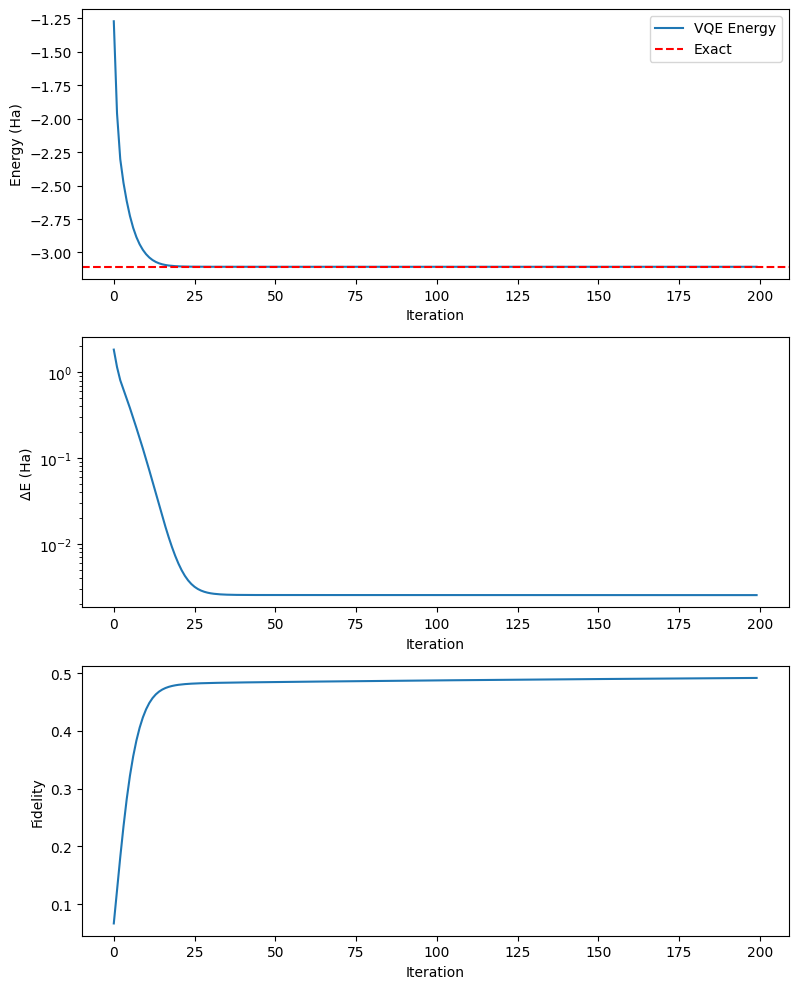

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(8, 10))

axes[0].plot(energy_history, label='VQE Energy')
axes[0].axhline(y=E_exact, color='r', linestyle='--', label='Exact')
axes[0].set_ylabel('Energy (Ha)')
axes[0].set_xlabel('Iteration')
axes[0].legend()

axes[1].plot(delta_E_history)
axes[1].set_ylabel('ΔE (Ha)')
axes[1].set_xlabel('Iteration')
axes[1].set_yscale('log')

axes[2].plot(fidelity_history)
axes[2].set_ylabel('Fidelity')
axes[2].set_xlabel('Iteration')

plt.tight_layout()
plt.show()